***predicting custormer churn using machine learning model to classify customers as exited or retained***

***import libraries***

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,classification_report

In [4]:
#load dataset
cust_churn=pd.read_csv("Churn_Modelling.csv")
cust_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
#drop colums
cust_churn.drop(columns=["RowNumber","Surname"],axis=1,inplace=True)

In [6]:
cust_churn.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
#check dataset
cust_churn["Exited"].value_counts(normalize=True)
#cust_churn.value_counts("Exited")#dataset is imbalanced

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [8]:
#check null values
cust_churn.isnull().sum()

CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
#geography column
cust_churn=pd.get_dummies(cust_churn,columns=["Geography"],drop_first=True,dtype=int)

In [10]:
#categorical to numerical change using map function
cust_churn["Gender"]=cust_churn["Gender"].map({"Male":0,"Female":1}).astype(int)

In [11]:
#summarizing dataset
print(cust_churn.head())
print(cust_churn.describe())
print(cust_churn.shape)

   CustomerId  CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  \
0    15634602          619       1   42       2       0.00              1   
1    15647311          608       1   41       1   83807.86              1   
2    15619304          502       1   42       8  159660.80              3   
3    15701354          699       1   39       1       0.00              2   
4    15737888          850       1   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0          1               1        101348.88       1                  0   
1          0               1        112542.58       0                  0   
2          1               0        113931.57       1                  0   
3          0               0         93826.63       0                  0   
4          1               1         79084.10       0                  0   

   Geography_Spain  
0                0  
1                1  
2                

In [12]:
#check duplicated values
cust_churn.duplicated().sum()

np.int64(0)

In [13]:
#segregating dataset
x=cust_churn.drop(["CustomerId","Exited"],axis=1)
x

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,39,5,0.00,2,1,0,96270.64,0,0
9996,516,0,35,10,57369.61,1,1,1,101699.77,0,0
9997,709,1,36,7,0.00,1,0,1,42085.58,0,0
9998,772,0,42,3,75075.31,2,1,0,92888.52,1,0


In [14]:
y=cust_churn["Exited"]
print(y.shape)

(10000,)


In [15]:
#splitting dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
x_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
4901,673,0,59,0,178058.06,2,0,1,21063.71,0,0
4375,850,0,41,8,60880.68,1,1,0,31825.84,1,0
6698,725,1,31,6,0.00,1,0,0,61326.43,0,0
9805,644,0,33,7,174571.36,1,0,1,43943.09,0,0
1101,703,0,29,9,0.00,2,1,0,50679.48,0,1
...,...,...,...,...,...,...,...,...,...,...,...
5734,768,0,54,8,69712.74,1,1,1,69381.05,0,0
5191,682,1,58,1,0.00,1,1,1,706.50,0,0
5390,735,1,38,1,0.00,3,0,0,92220.12,0,0
860,667,0,43,8,190227.46,1,1,0,97508.04,0,0


In [33]:
#feature scaling
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)
x_train

array([[ 0.21835119, -0.91186722,  1.91661905, ..., -1.38284424,
        -0.57776083, -0.57735027],
       [ 2.05728037, -0.91186722,  0.20210899, ..., -1.19589044,
         1.73082   , -0.57735027],
       [ 0.75860157,  1.09665089, -0.75039661, ..., -0.68342242,
        -0.57776083, -0.57735027],
       ...,
       [ 0.86249588,  1.09665089, -0.08364269, ..., -0.14675423,
        -0.57776083, -0.57735027],
       [ 0.15601461, -0.91186722,  0.3926101 , ..., -0.0548954 ,
        -0.57776083, -0.57735027],
       [ 0.46769752, -0.91186722,  1.15461458, ..., -0.81796934,
         1.73082   , -0.57735027]], shape=(7500, 11))

<Axes: >

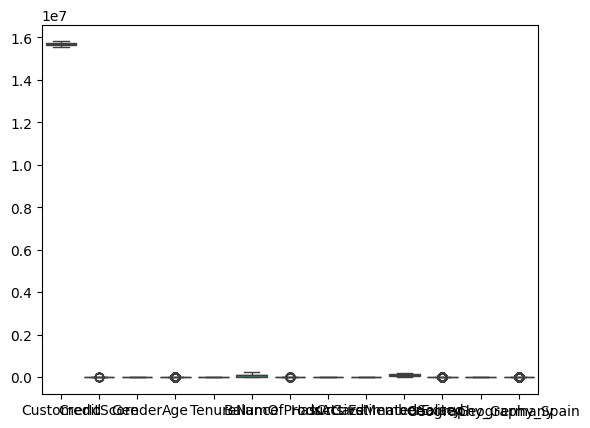

In [17]:
#exploratory data analysis
#check outliers
sns.boxplot(cust_churn)

In [31]:
numerical_cols=["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary"]
numerical_cols

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

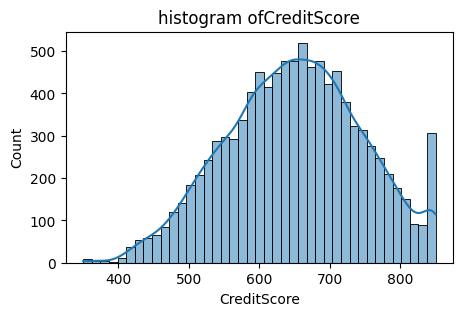

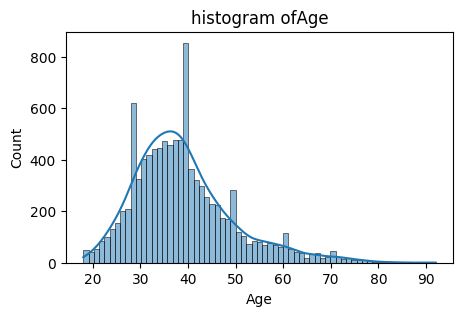

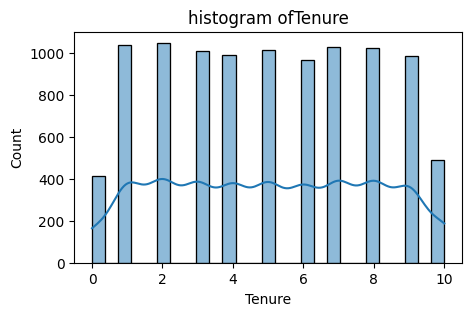

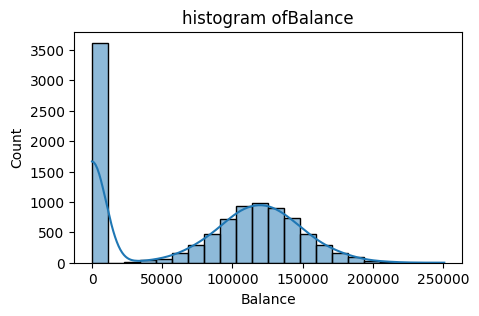

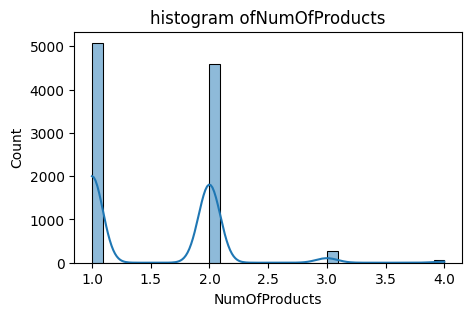

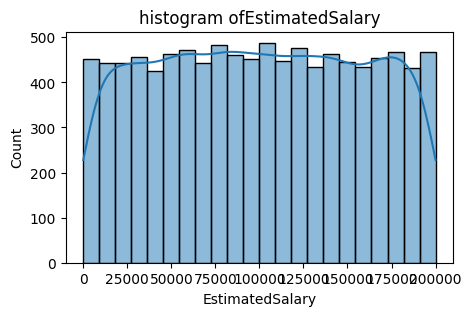

In [32]:
#distribution check
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(data=cust_churn,x=col,kde=True)#normal distribution
    plt.title(f"histogram of{col}")
    plt.show()

    #credit score distribution is slightly left skewed
    #age distribution is slightly right skewed

In [20]:
#check correlation
cust_churn.corr()

,CustomerId,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CustomerId,1.000000,0.005308,0.002641,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248,-0.003097,0.007800
CreditScore,0.005308,1.000000,0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,0.002641,0.002857,1.000000,0.027544,-0.014733,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512,0.024628,-0.016889
Age,0.009497,-0.003965,0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,-0.014883,0.000842,-0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,-0.012419,0.006268,-0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.016972,0.012238,0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.014025,-0.005458,-0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.001665,0.025651,-0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,0.015271,-0.001384,0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482


<Axes: >

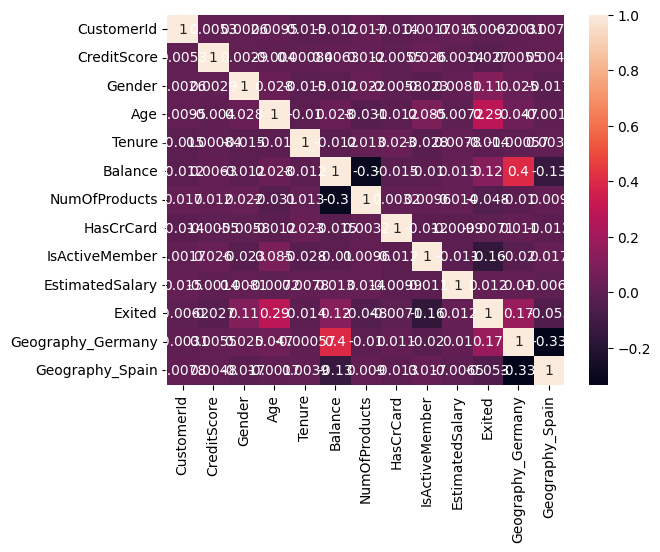

In [21]:
sns.heatmap(cust_churn.corr(),annot=True)

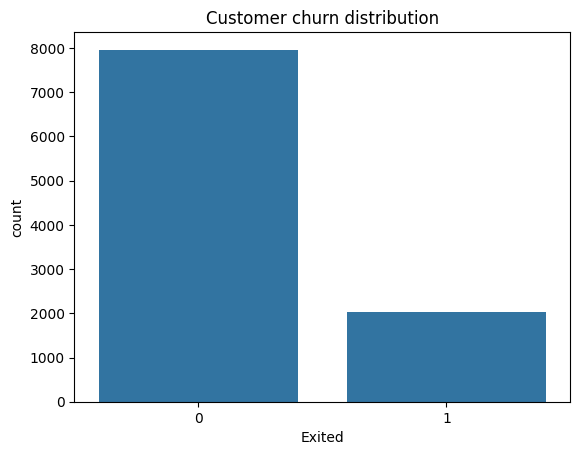

In [27]:
#target column countplot
sns.countplot(data=cust_churn,x="Exited")
plt.title("Customer churn distribution")
plt.show()

In [28]:
#using smote analysis
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_bal,y_train_bal=smote.fit_resample(x_train,y_train)
print(y_train.value_counts())
print(y_train_bal.value_counts())

Exited
0    5960
1    1540
Name: count, dtype: int64
Exited
1    5960
0    5960
Name: count, dtype: int64


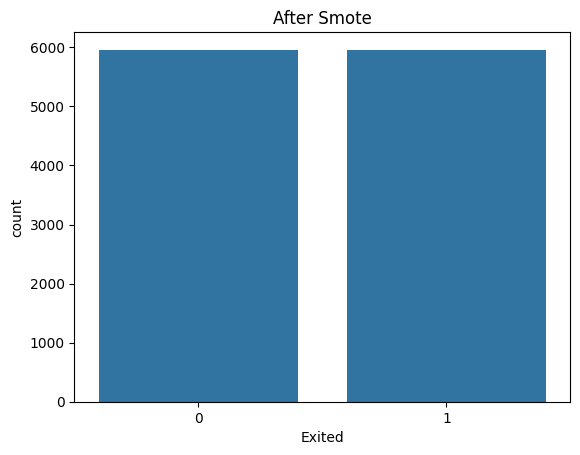

In [29]:
#after smote analysis
sns.countplot(x=y_train_bal)
plt.title("After Smote")
plt.show()

In [30]:
#try multiple algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
models={
    "LogisticRegression":LogisticRegression(),
    "DecisionTree":DecisionTreeClassifier(max_depth=5,random_state=42),
    "RandomForest":RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
}
results=[]
for name,model in models.items():
    model.fit(x_train_bal,y_train_bal)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    pre=precision_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    
    results.append([name,acc,pre,rec])
compare=pd.DataFrame(results,columns=["Model","Accuracy","Precison","Recall"])
print(compare)

                Model  Accuracy  Precison    Recall
0  LogisticRegression    0.7204  0.388521  0.708249
1        DecisionTree    0.4316  0.229508  0.788732
2        RandomForest    0.6636  0.349387  0.802817
